In [1]:
import trimesh

input_file = '/PHShome/yl535/project/python/datasets/animal3d/obj_files/test/n02085782/n02085782_1448.obj'
# Load the mesh
mesh = trimesh.load(input_file)

# This will open a window and render the object
mesh.show()

In [6]:
import os
import imageio
import uuid
from IPython.display import Image as ImageDisplay
from inference import Inference, ready_gaussian_for_video_rendering, render_video, load_image, load_single_mask, load_mask, display_image, make_scene, interactive_visualizer

import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from transformers import pipeline
from io import BytesIO

# os.environ["CUDA_VISIBLE_DEVICES"] = "3"

def show_masks(image, masks):
    """
    Helper function to display the image with masks overlaid.
    """
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    # Iterate through each mask and overlay it
    for mask in masks:
        # Convert PIL mask to numpy array (boolean)
        m = np.array(mask) > 0 
        
        # Generate a random color for this mask
        color = np.concatenate([np.random.random(3), [0.6]]) # [R, G, B, Alpha]
        
        # Create a colored mask image
        h, w = m.shape
        mask_image = m.reshape(h, w, 1) * color.reshape(1, 1, -1)
        
        # Overlay the mask
        ax.imshow(mask_image)

    plt.axis('off')
    plt.show()

In [3]:
PATH = os.getcwd()
TAG = "hf"
config_path = f"{PATH}/../checkpoints/{TAG}/pipeline.yaml"
config_path = f"{PATH}/../checkpoints/checkpoints/pipeline.yaml"
inference = Inference(config_path, compile=False)

device = 0 if torch.cuda.is_available() else -1
# generator = pipeline(
#     "mask-generation", 
#     model="facebook/sam2-hiera-large", 
#     device=device,
#     torch_dtype=torch.float32 
# )

2026-02-03 01:43:38.093 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


/shared/ssd_28T/home/yl535/anaconda3/envs/sam3d-objects/lib/python3.11/site-packages/moge/model/v1.py:171: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")
2026-02-03 01:43:43.003 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-02-03 01:43:43.005 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:98 - self.device: cuda
2026-02-03 01:43:43.005 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:99 - CUDA_VISIBLE_DEVICES: None
2026-02-03 01:43:43.005 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:100 - Actually using GPU: 0
2026-02-03 01:43:43.005 | INFO     | sam3d_objects.pipeline.inference_pipeline:init_pose_decoder:295 - Using pose decoder: ScaleShiftInvariant
2026-02-03 01:43:43.006 | INFO     | 

In [8]:
file_path = "/PHShome/yl535/project/python/datasets/animal3d/images/test/n02085782/n02085782_1448.JPEG"
mask_path = "/PHShome/yl535/project/python/datasets/animal3d/masks/test/n02085782/n02085782_1448.png"

image = Image.open(file_path)

IMAGE_NAME = os.path.basename(file_path).split('.')[0]
print(IMAGE_NAME)

masks = [load_mask(mask_path)]

n02085782_1448


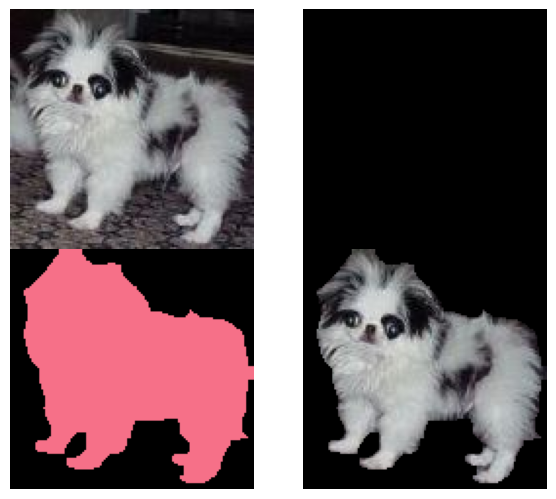

In [10]:
mask_index=0
image_np = np.array(image)
display_image(image_np, masks=[masks[mask_index]])

In [11]:
output = inference(image_np, masks[mask_index], seed=42)

# export gaussian splat (as point cloud)
output["gs"].save_ply(f"{PATH}/gaussians/single/{IMAGE_NAME}.ply")

2026-02-03 01:53:46.324 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:662 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-02-03 01:53:46.325 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:631 - Running condition embedder ...
2026-02-03 01:53:46.541 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:635 - Condition embedder finishes!
2026-02-03 01:53:49.114 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:712 - Downsampled coords from 18543 to 18506
2026-02-03 01:53:49.139 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:368 - Rescaling scale by 1 after downsampling
2026-02-03 01:53:49.140 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:742 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-02-03 01:53:49.140 | INFO     | sam

In [12]:
# render gaussian splat
scene_gs = make_scene(output)
scene_gs = ready_gaussian_for_video_rendering(scene_gs)

video = render_video(
    scene_gs,
    r=1,
    fov=60,
    pitch_deg=15,
    yaw_start_deg=-45,
    resolution=512,
)["color"]

# save video as gif
imageio.mimsave(
    os.path.join(f"{PATH}/gaussians/single/{IMAGE_NAME}.gif"),
    video,
    format="GIF",
    duration=1000 / 30,  # default assuming 30fps from the input MP4
    loop=0,  # 0 means loop indefinitely
)

# notebook display
ImageDisplay(url=f"gaussians/single/{IMAGE_NAME}.gif?cache_invalidator={uuid.uuid4()}")

Rendering: 300it [00:01, 182.04it/s]


In [ ]:
print(f"{PATH}/gaussians/single/{IMAGE_NAME}.gif")

NameError: name 'PATH' is not defined